# Task 1: Frequently Bought Together

This notebook implements an Association Rule Mining system to identify items frequently bought together from customer purchase history, using the FP-Growth algorithm.


In [22]:
# Install once if needed:
# !pip install mlxtend

## Install & Import Libraries

In [102]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.model_selection import train_test_split

random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Load & Inspect Dataset

In [121]:
df = pd.read_csv('Groceries_dataset.csv')

print('Shape:', df.shape)
print('\nFirst 10 rows:')
df.head(10)

Shape: (38765, 3)

First 10 rows:


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


## Data Cleaning & Preprocessing

In [104]:
# Rename columns for clarity
df.columns = ['customer_id', 'date', 'item']

# Drop nulls
df.dropna(inplace=True)

# Standardise item names: lowercase and strip whitespace
df['item'] = df['item'].str.strip().str.lower()

# Parse date column
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print(f'Total transactions (rows): {len(df)}')
print(f'Unique customers: {df["customer_id"].nunique()}')
print(f'Unique items: {df["item"].nunique()}')
df.head()

Total transactions (rows): 38765
Unique customers: 3898
Unique items: 167


,customer_id,date,item
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


## Exploratory Data Analysis (EDA)

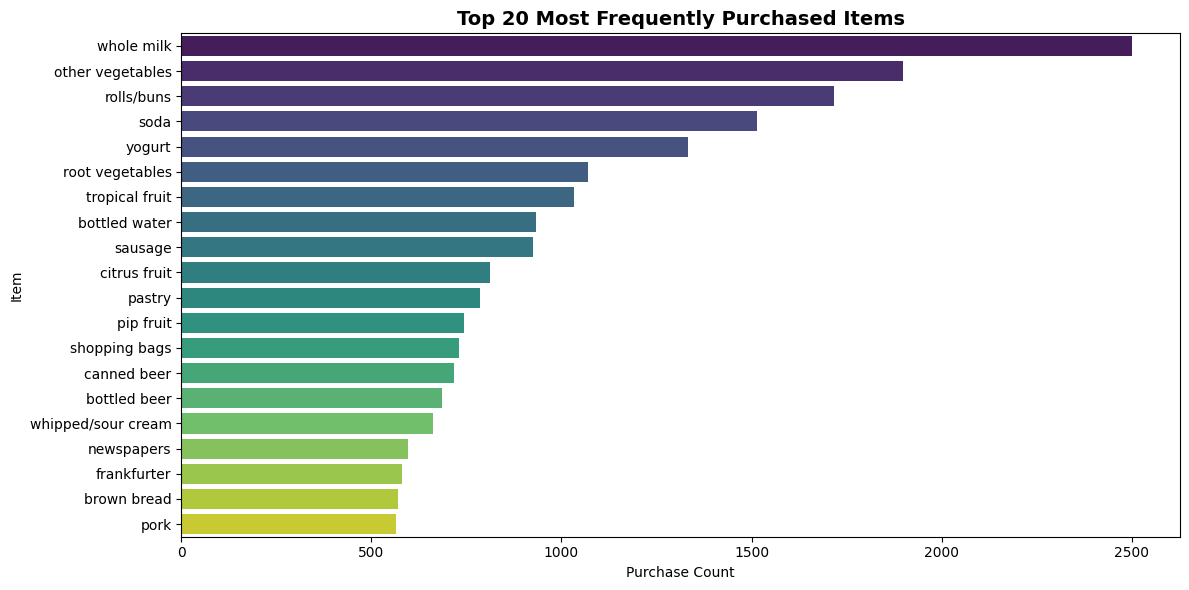

In [105]:
# Top 20 Most Purchased Items
top_items = df['item'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='viridis', legend=False)
plt.title('Top 20 Most Frequently Purchased Items', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Count')
plt.ylabel('Item')
plt.tight_layout()
plt.savefig('top_items.png', dpi=150)
plt.show()

This chart shows the most commonly purchased products in the dataset, helping highlight the dominant items that are likely to influence association rule generation.

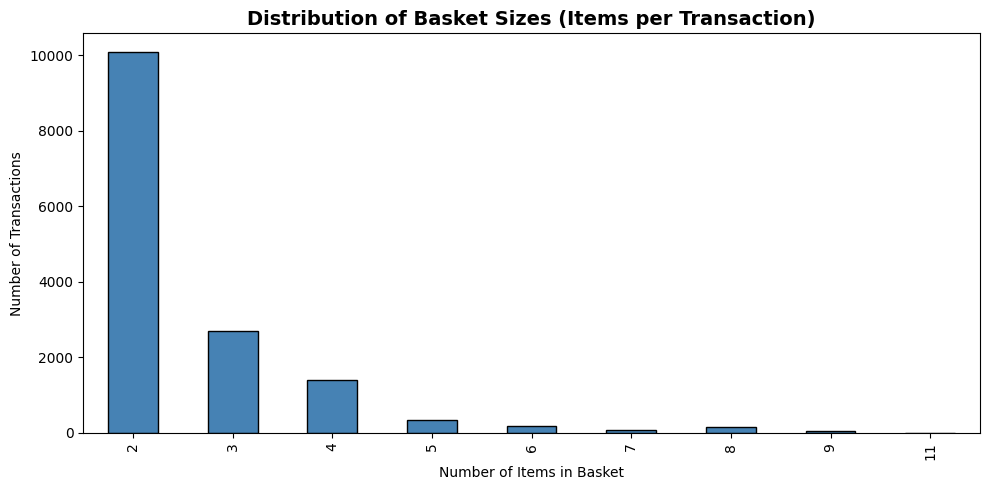

Average basket size: 2.59 items
Max basket size: 11 items


In [106]:
# Transaction Size Distribution
basket_sizes = df.groupby(['customer_id', 'date'])['item'].count()

plt.figure(figsize=(10, 5))
basket_sizes.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Basket Sizes (Items per Transaction)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Items in Basket')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig('basket_sizes.png', dpi=150)
plt.show()

print(f'Average basket size: {basket_sizes.mean():.2f} items')
print(f'Max basket size: {basket_sizes.max()} items')

Here you can see how many items customers typically buy per transaction, giving context on basket sparsity and the structure of the data used for rule mining.

## Build Transaction Matrix
Group each customer's shopping trip (customer + date) into a single basket, then one-hot encode for FP-Growth.

In [107]:
# Group into baskets
baskets = df.groupby(['customer_id', 'date'])['item'].apply(list).reset_index()
baskets.columns = ['customer_id', 'date', 'items']
baskets = baskets[baskets['items'].apply(len) >= 2].reset_index(drop=True)


print(f'Total baskets (shopping trips): {len(baskets)}')
baskets.head()

Total baskets (shopping trips): 14963


,customer_id,date,items
0,1000,2014-06-24,"[whole milk, pastry, salty snack]"
1,1000,2015-03-15,"[sausage, whole milk, semi-finished bread, yog..."
2,1000,2015-05-27,"[soda, pickled vegetables]"
3,1000,2015-07-24,"[canned beer, misc. beverages]"
4,1000,2015-11-25,"[sausage, hygiene articles]"


In [108]:
# One-hot encode using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(baskets['items'])
basket_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded matrix shape: {basket_encoded.shape}')

Encoded matrix shape: (14963, 167)


## Train / Test Split
Split baskets into 80% training and 20% test sets before mining rules.

In [109]:
train_baskets, test_baskets = train_test_split(baskets, test_size=0.2, random_state=42)

print(f'Training baskets: {len(train_baskets)}')
print(f'Test baskets:     {len(test_baskets)}')

# Encode training set only
te_train = TransactionEncoder()
train_array = te_train.fit_transform(train_baskets['items'])
train_encoded = pd.DataFrame(train_array, columns=te_train.columns_)
print('Training set encoded successfully.')

Training baskets: 11970
Test baskets:     2993
Training set encoded successfully.


## FP-Growth: Frequent Itemsets
FP-Growth used as it is generally more efficient than Apriori for mining frequent itemsets in larger transaction datasets.

In [110]:
# Mine frequent itemsets
# min_support=0.001 means the itemset must appear in at least 0.1% of all baskets
frequent_itemsets = fpgrowth(train_encoded, min_support=0.001, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'Total frequent itemsets found: {len(frequent_itemsets)}')
print(f'\nItemsets by size:')
print(frequent_itemsets['length'].value_counts().sort_index())
frequent_itemsets.sort_values('support', ascending=False).head()

Total frequent itemsets found: 764

Itemsets by size:
length
1    149
2    606
3      9
Name: count, dtype: int64


,support,itemsets,length
3,0.161153,(whole milk),1
21,0.123475,(other vegetables),1
4,0.107853,(rolls/buns),1
15,0.096575,(soda),1
43,0.086216,(yogurt),1


## Generate Association Rules
From the mined frequent itemsets, it generates association rules of the form IF {A} THEN {B}, where the consequent represents items likely to co-occur with the antecedent.

In [111]:
# Generate rules with minimum confidence of 0.1 (10%)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)

# Filter for meaningful rules: lift > 1 (positive association only)
rules = rules[rules['lift'] > 1.0].sort_values('lift', ascending=False)

print(f'Total association rules generated: {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

Total association rules generated: 43


,antecedents,consequents,support,confidence,lift
45,"(whole milk, yogurt)",(sausage),0.001420,0.123188,2.045167
46,"(whole milk, sausage)",(yogurt),0.001420,0.158879,1.842806
79,"(pastry, soda)",(whole milk),0.001170,0.291667,1.809876
80,"(pastry, whole milk)",(soda),0.001170,0.164706,1.705475
29,(flour),(tropical fruit),0.001086,0.113043,1.678822


## Association Rules Chart

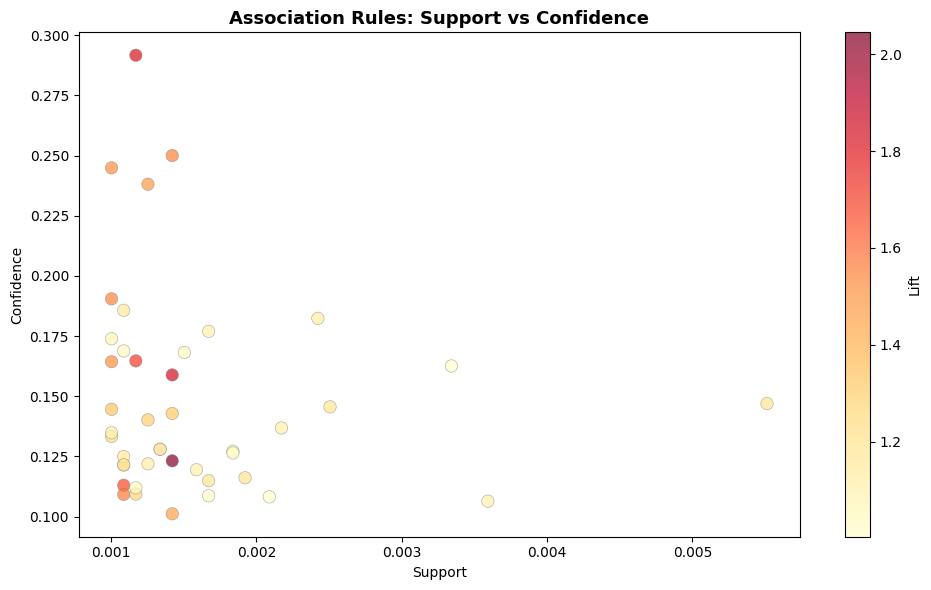

In [112]:
# Support vs Confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='grey',
    linewidths=0.4,
    s=80
)
plt.colorbar(scatter, label='Lift')
plt.title('Association Rules: Support vs Confidence', fontsize=13, fontweight='bold')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.savefig('rules_scatter.png', dpi=150)
plt.show()

The scatter plot shows the relationship between rule, support, and confidence, while lift indicates the strength of each rule beyond random co-occurrence.

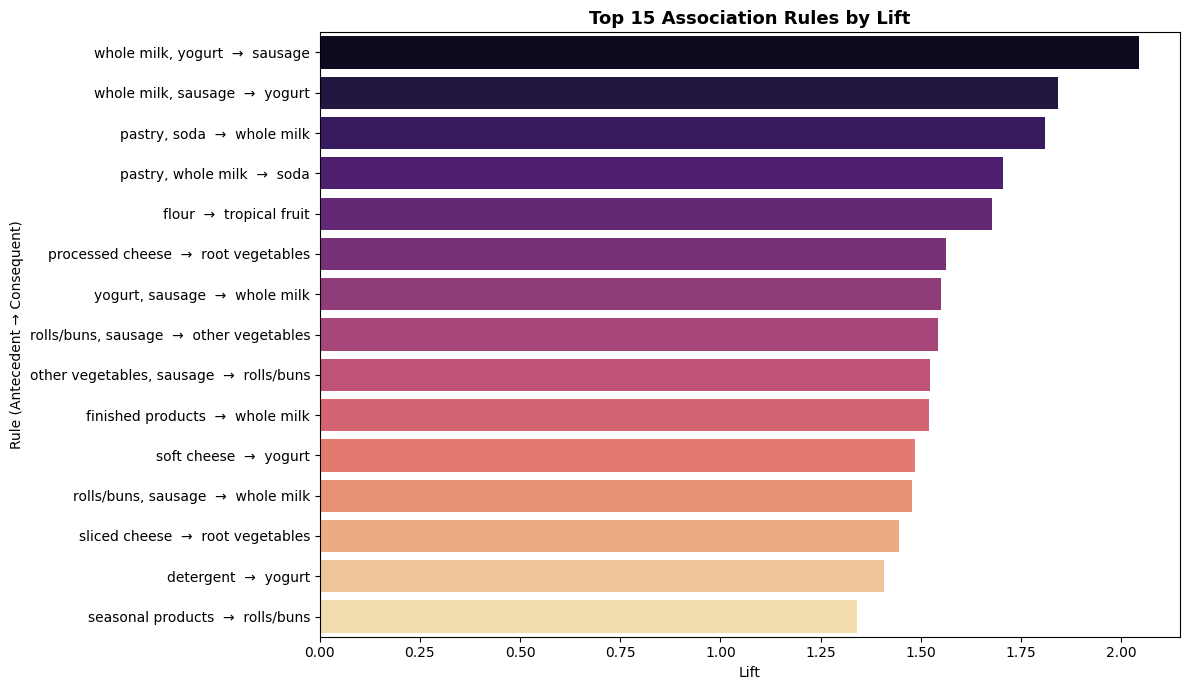

In [113]:
# Top 15 Rules by Lift
top_rules = rules.head(15).copy()
top_rules['rule'] = top_rules.apply(
    lambda row: ', '.join(list(row['antecedents'])) + '  →  ' + ', '.join(list(row['consequents'])),
    axis=1
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_rules, x='lift', y='rule', hue='rule', palette='magma', legend=False)
plt.title('Top 15 Association Rules by Lift', fontsize=13, fontweight='bold')
plt.xlabel('Lift')
plt.ylabel('Rule (Antecedent → Consequent)')
plt.tight_layout()
plt.savefig('top_rules_lift.png', dpi=150)
plt.show()

This chart highlights the strongest item associations discovered by the model, ranked by lift to show the most meaningful co-purchase patterns.

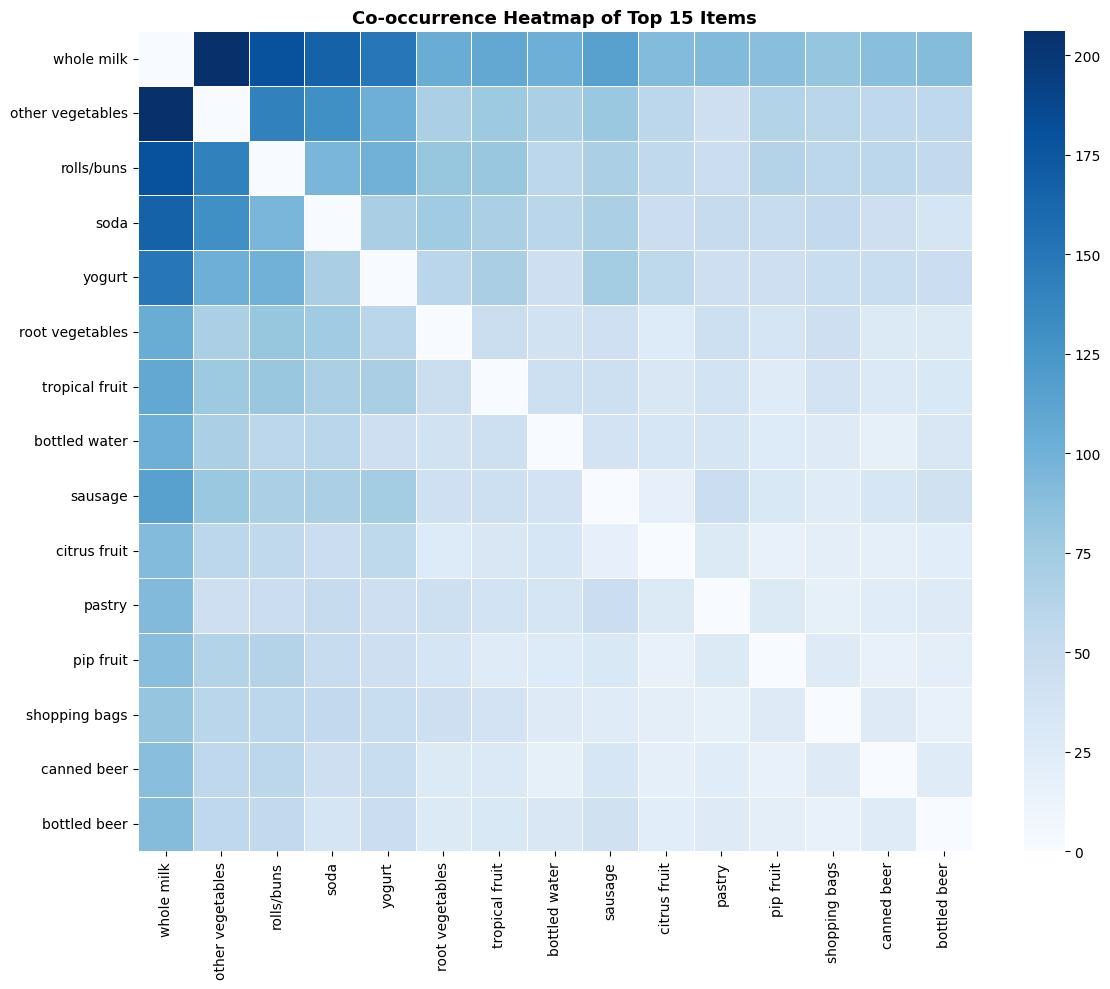

In [114]:
# Co-occurrence of top items
top_n_items = df['item'].value_counts().head(15).index.tolist()
cooccurrence = pd.DataFrame(0, index=top_n_items, columns=top_n_items)

for items in train_baskets['items']:
    items_in_top = [i for i in items if i in top_n_items]
    for i in items_in_top:
        for j in items_in_top:
            if i != j:
                cooccurrence.loc[i, j] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence, cmap='Blues', linewidths=0.5, annot=False)
plt.title('Co-occurrence Heatmap of Top 15 Items', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150)
plt.show()

This heatmap shows how often the most common items appear together in the same baskets, helping reveal broader purchase relationships in the dataset.

## Recommendation Function
Given a customer's current basket, return the top-N recommendations based on learned co-purchase rules that overlap with the basket contents.

In [115]:
def recommend_frequently_bought_together(basket, rules_df, top_n=5, verbose=True):
    basket_set = set(item.lower().strip() for item in basket)
    recommendations = []

    for _, row in rules_df.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])

        # Check if the basket shares at least one item with the rule antecedent
        if len(antecedents & basket_set) > 0:
            for item in consequents:
                if item not in basket_set: 
                    recommendations.append({
                        'recommended_item': item,
                        'because_you_bought': ', '.join(antecedents),
                        'confidence': round(row['confidence'], 3),
                        'lift': round(row['lift'], 3)
                    })

    if not recommendations:
        if verbose:
            print(f'No recommendations found for basket: {basket}')
            print('Tip: Try items that appear frequently in the dataset.')
        return pd.DataFrame()

    rec_df = pd.DataFrame(recommendations)
    # Remove duplicates: keep highest lift per recommended item
    rec_df = rec_df.sort_values('lift', ascending=False).drop_duplicates('recommended_item')
    return rec_df.head(top_n).reset_index(drop=True)

In [116]:
# Example
customer_basket = ['whole milk']

print(f'Customer basket: {customer_basket}')
print('Frequently Bought Together Recommendations:')

recs = recommend_frequently_bought_together(customer_basket, rules, top_n=5)
if not recs.empty:
    print(recs.to_string(index=False))

Customer basket: ['whole milk']
Frequently Bought Together Recommendations:
recommended_item  because_you_bought  confidence  lift
         sausage  whole milk, yogurt       0.123 2.045
          yogurt whole milk, sausage       0.159 1.843
            soda  pastry, whole milk       0.165 1.705
      rolls/buns whole milk, sausage       0.140 1.300


In [118]:
customer_basket_2 = ['yogurt']

print(f'Customer basket: {customer_basket_2}')
recs2 = recommend_frequently_bought_together(customer_basket_2, rules, top_n=10)
if not recs2.empty:
    print(recs2.to_string(index=False))

Customer basket: ['yogurt']
recommended_item because_you_bought  confidence  lift
         sausage whole milk, yogurt       0.123 2.045
      whole milk    yogurt, sausage       0.250 1.551


Recommendations are generated by matching the customer’s basket against learned association rules and selecting consequents from rules whose antecedents overlap with the basket. 

A partial-overlap matching strategy was adopted to improve recommendation coverage for smaller baskets, as strict antecedent matching often returned too few suggestions for practical marketplace use.

## Evaluation: Precision@K and Recall@K
The model was evaluated on a held-out test set by randomly hiding one item from each basket, generating recommendations from the remaining items, and checking whether the hidden item appeared within the top-K suggestions.

In [119]:
def evaluate_model(test_baskets_df, rules_df, k=5):
    precisions = []
    recalls = []

    # Only evaluate baskets with 2+ items
    valid_baskets = test_baskets_df[test_baskets_df['items'].apply(len) >= 2]

    for _, row in valid_baskets.iterrows():
        items = row['items']
        input_basket = items.copy()
        ground_truth_item = random.choice(input_basket)
        input_basket.remove(ground_truth_item)
        ground_truth = {ground_truth_item}

        recs = recommend_frequently_bought_together(input_basket, rules_df, top_n=k, verbose=False)

        if recs.empty:
            continue

        recommended_items = set(recs['recommended_item'].tolist())
        hits = len(recommended_items & ground_truth)

        precisions.append(hits / k)
        recalls.append(hits / len(ground_truth))

    return {
        f'Precision@{k}': round(np.mean(precisions), 4),
        f'Recall@{k}':    round(np.mean(recalls), 4),
        'Evaluated on':   len(valid_baskets)
    }


# Run evaluation
results = evaluate_model(test_baskets, rules, k=5)
print(' Model Evaluation Results:')
for metric, value in results.items():
    print(f'{metric}: {value}')

 Model Evaluation Results:
Precision@5: 0.0181
Recall@5: 0.0903
Evaluated on: 2993


K=1: Precision=0.0486, Recall=0.0486
K=3: Precision=0.0287, Recall=0.086
K=5: Precision=0.0181, Recall=0.0906
K=10: Precision=0.0093, Recall=0.0934


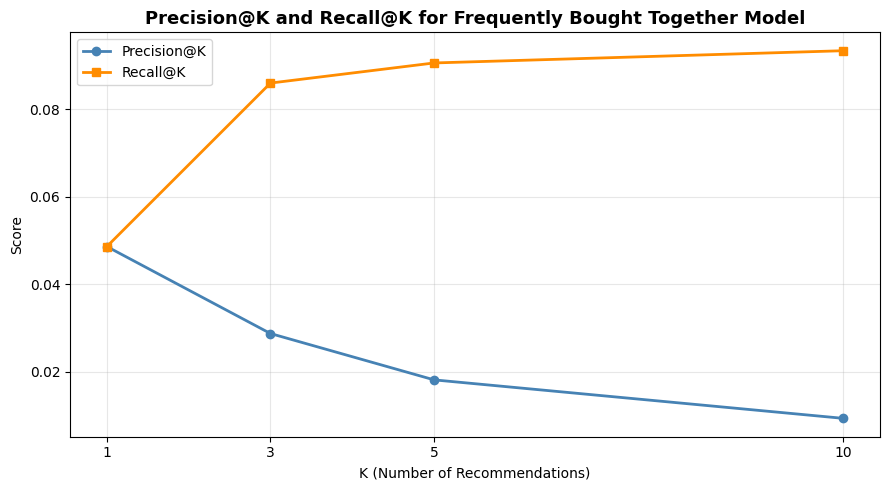

In [120]:
# Evaluate at multiple K values and plot
k_values = [1, 3, 5, 10]
precisions_list = []
recalls_list = []

for k in k_values:
    res = evaluate_model(test_baskets, rules, k=k)
    precisions_list.append(res[f'Precision@{k}'])
    recalls_list.append(res[f'Recall@{k}'])
    print(f'K={k}: Precision={res[f"Precision@{k}"]}, Recall={res[f"Recall@{k}"]}')

# Plot
plt.figure(figsize=(9, 5))
plt.plot(k_values, precisions_list, marker='o', label='Precision@K', color='steelblue', linewidth=2)
plt.plot(k_values, recalls_list, marker='s', label='Recall@K', color='darkorange', linewidth=2)
plt.title('Precision@K and Recall@K for Frequently Bought Together Model', fontsize=13, fontweight='bold')
plt.xlabel('K (Number of Recommendations)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_at_k.png', dpi=150)
plt.show()

And here you can see how recommendation performance changes as the number of returned suggestions increases, displaying the trade-off between precision and recall.